# PlantCV Practice Notebook

Practice running a PlantCV analysis cell-by-cell, the way tomorrow's workshop
will work. This walks through the same pipeline as
`scripts/analyze_plant.py`, broken into steps so you can run one cell at a
time, inspect the image after each step, and tweak parameters to see what
changes.

Uses a real sample photo (a maize B73 seedling in sand) from the Danforth
Center's official
[VIS single-plant tutorial](https://github.com/danforthcenter/plantcv-tutorial-v4-VIS-single-plant).

**Kernel:** make sure this notebook is running the `plantcv` conda
environment as its kernel (Kernel -> Change Kernel -> plantcv), then run
cells top to bottom with Shift+Enter.

In [1]:
%matplotlib inline
import os
from plantcv import plantcv as pcv

IMG_PATH = os.path.join("..", "scripts", "data", "B73_sand_2023-04-14.jpg")

pcv.params.debug = "plot"   # show each step's output inline as we go
pcv.params.dpi = 100
pcv.params.text_size = 15
pcv.params.text_thickness = 8
pcv.params.sample_label = 'default'

## 1. Read in the image

`pcv.readimage` returns the image array, its path, and filename.

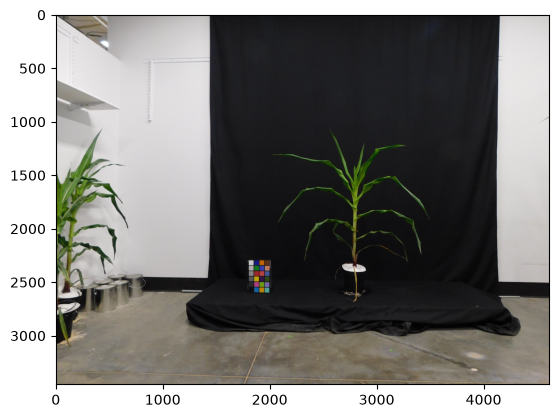

shape: (3456, 4608, 3)


In [2]:
img, path, filename = pcv.readimage(filename=IMG_PATH)
print("shape:", img.shape)

## 2. Crop

The raw photo includes background beyond what we need. Crop coordinates are
tuned to this specific photo's framing -- if you use a different photo,
you'll need to find new values (try plotting `img` first and reading pixel
coordinates off the axes).

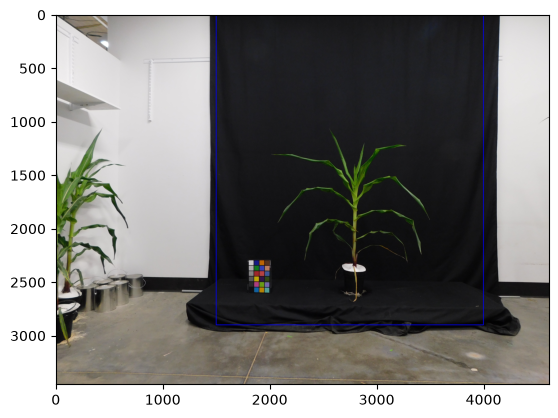

In [3]:
crop_img = pcv.crop(img=img, x=1500, y=0, h=2900, w=2500)

## 3. Color-correct using the color card

The photo includes a color checker card. PlantCV detects it, then
transforms the image's colors to match known standard values -- this makes
thresholds consistent regardless of lighting conditions on the day a photo
was taken.

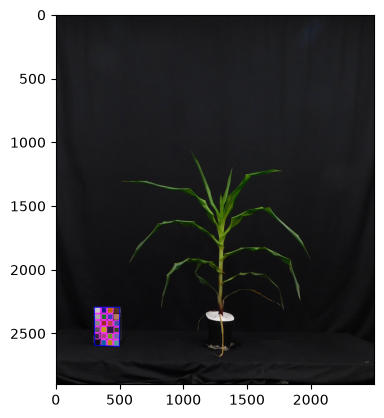

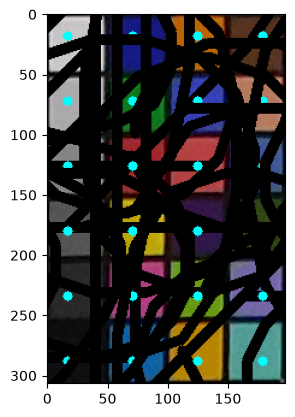

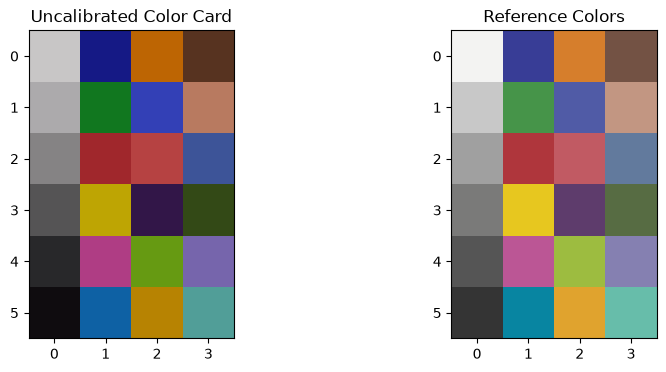

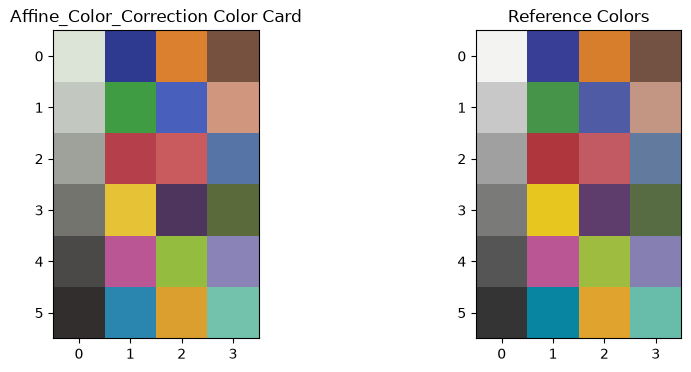

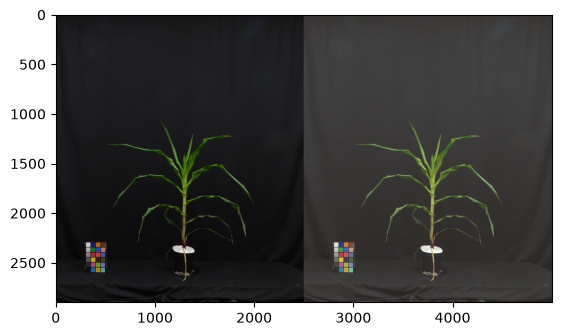

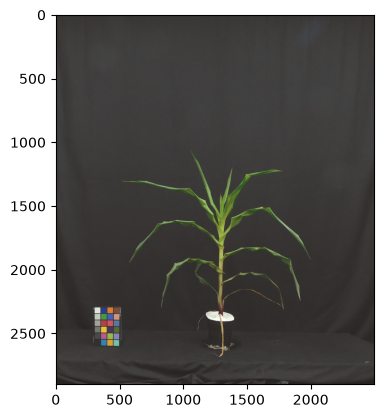

In [4]:
source_matrix = pcv.transform.detect_color_card(rgb_img=crop_img)
std_matrix = pcv.transform.std_color_matrix(pos=3)
img_cc = pcv.transform.affine_color_correction(crop_img, source_matrix, std_matrix)
pcv.plot_image(img_cc)

## 4. Look at color channels to pick a threshold

Different color spaces (RGB, HSV, LAB) separate the plant from the
background differently. Look at which channel makes the plant most
distinct -- that's what we'll threshold on.

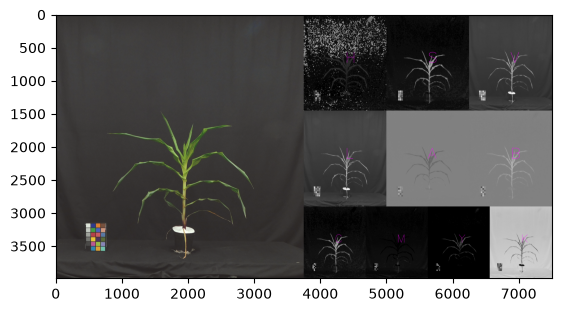

In [5]:
colorspace_img = pcv.visualize.colorspaces(rgb_img=img_cc)

## 5. Threshold the plant out of the background

The LAB **a** (green-magenta) and **b** (blue-yellow) channels separate
green plant tissue from soil/background well. `dual_channels` draws a line
between two points you pick in (a, b) space and keeps everything on one
side of it.

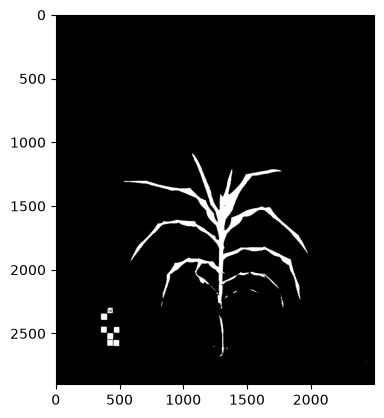

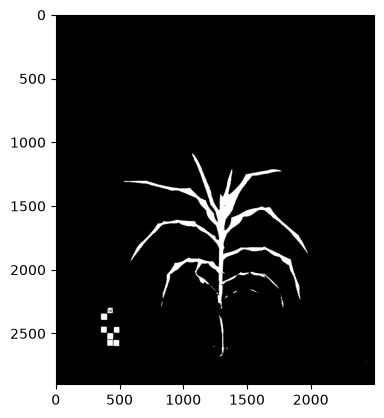

In [6]:
thresh = pcv.threshold.dual_channels(
    rgb_img=img_cc, x_channel="a", y_channel="b",
    points=[(80, 80), (125, 140)], above=True
)
pcv.plot_image(thresh)

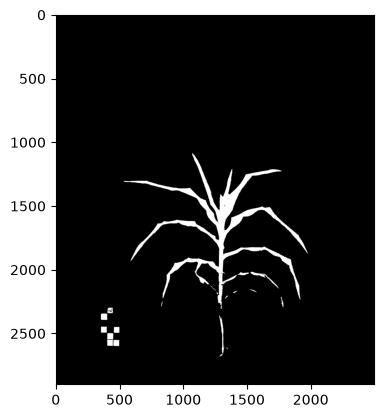

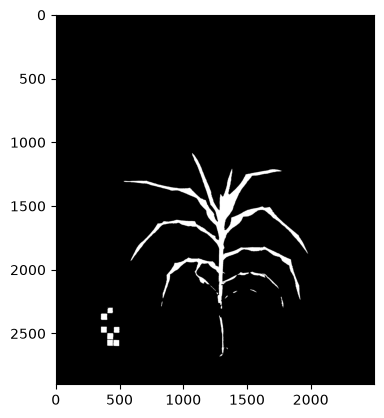

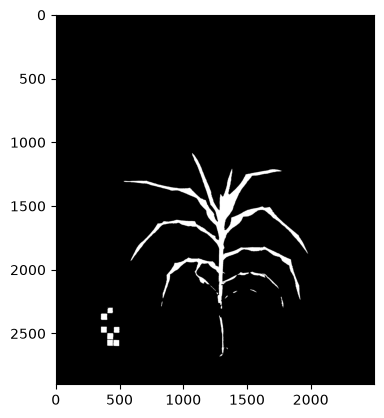

In [7]:
# Fill small noise specks and close small holes inside leaves
filled = pcv.fill(bin_img=thresh, size=50)
filled = pcv.fill_holes(filled)
pcv.plot_image(filled)

## 6. Restrict to a region of interest (ROI)

We only want the plant, not the color card. Define a rectangle that covers
the plant but excludes the card, then filter the mask to that region.

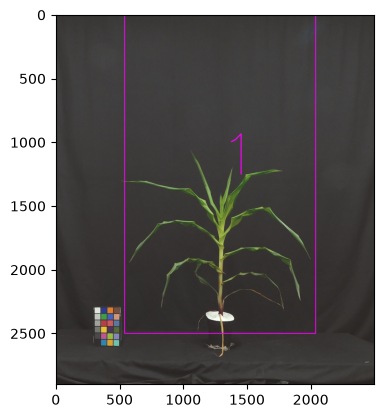

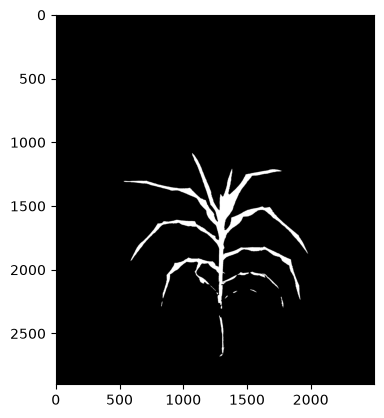

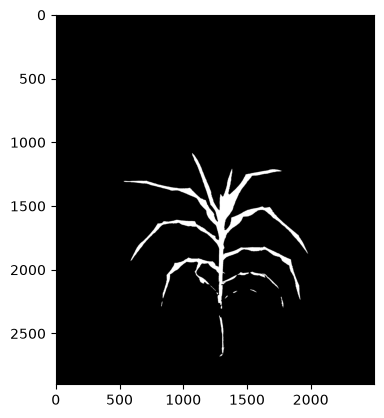

In [8]:
roi = pcv.roi.rectangle(img=img_cc, x=540, y=0, h=2500, w=1500)
kept_mask = pcv.roi.filter(mask=filled, roi=roi, roi_type="partial")
pcv.plot_image(kept_mask)

## 7. Extract traits

`analyze.size` measures shape/size (area, height, width, solidity, ...).
`analyze.color` measures color distribution across color spaces. Both
automatically record their results into `pcv.outputs`.

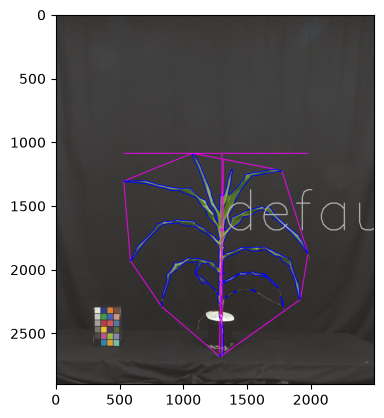

In [9]:
pcv.outputs.clear()
size_img = pcv.analyze.size(img=img_cc, labeled_mask=kept_mask)

In [10]:
color_img = pcv.analyze.color(rgb_img=img_cc, labeled_mask=kept_mask, colorspaces="all")

alt.FacetChart(...)

## 8. Look at the extracted trait values

In [11]:
for sample, traits in pcv.outputs.observations.items():
    for name, obs in traits.items():
        value = obs["value"]
        if isinstance(value, list):
            continue  # skip full histograms/spectra here
        print(f"[{sample}] {name}: {value} {obs['scale']}")

[default_1] in_bounds: True none
[default_1] area: 203697.0 pixels
[default_1] convex_hull_area: 1642401.5 pixels
[default_1] solidity: 0.12402387601326473 none
[default_1] perimeter: 22852.813225746155 pixels
[default_1] total_edge_length: 17620.729932427406 pixels
[default_1] width: 1447 pixels
[default_1] height: 1595 pixels
[default_1] longest_path: 1506.3837492485106 pixels
[default_1] center_of_mass_x: 1304.2562433418263 none
[default_1] center_of_mass_y: 1687.2287122539851 none
[default_1] convex_hull_vertices: 16 none
[default_1] object_in_frame: True none
[default_1] ellipse_center_x: 1285.175048828125 none
[default_1] ellipse_center_y: 1795.8846435546875 none
[default_1] ellipse_major_axis: 1301.5401611328125 pixels
[default_1] ellipse_minor_axis: 1102.6707763671875 pixels
[default_1] ellipse_angle: 139.63140869140625 degrees
[default_1] ellipse_eccentricity: 0.5312667988892628 none
[default_1] saturation_mean: 45.29744920054748 percent
[default_1] saturation_median: 45.49019

## 9. Save results to a file

`save_results` writes everything recorded in `pcv.outputs` (including the
full histograms skipped above) to a JSON file for downstream analysis.

In [12]:
pcv.outputs.save_results(filename="practice_results.json")
print("saved.")

saved.


## Try it yourself

- Swap `IMG_PATH` for one of your own phone photos of a plant (against a
  plain-ish background) and redo the crop/threshold/ROI steps for it.
- Try different threshold points in step 5 and see how the mask changes.
- Explore `pcv.analyze.bound_horizontal` / `bound_vertical` for
  height-relative-to-a-line measurements.